# Collaborative Filtering
SVD (Matrix Factorization) si Neighborhood CF (Adjusted Cosine)

In [ ]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from ml.preprocess import load_data
from ml.collaborative import CollaborativeRecommender

In [ ]:
ratings, movies, tags, links = load_data(
    ratings_path="../data/ratings.csv",
    movies_path="../data/movies.csv",
    tags_path="../data/tags.csv",
    links_path="../data/links.csv"
)

In [ ]:
# Antrenare model SVD (Truncated SVD, k=50 factori latenti)
svd_model = CollaborativeRecommender(random_state=42)
svd_model.load_ratings(ratings)
svd_model.build_user_matrix()
print(f"CF SVD antrenat: {svd_model.item_factors.shape[0]} filme × {svd_model.item_factors.shape[1]} factori latenti")
print(f"Matrice user-item: {svd_model.user_matrix_raw.shape}")

In [ ]:
# Evaluare offline: Precision@10 si NDCG@10
# SVD (metoda principala) vs Neighborhood CF (Adjusted Cosine - fallback)

eval_users = ratings.groupby("userId").size()
eval_users = eval_users[eval_users >= 20].index.tolist()[:50]

def precision_at_k(recommended, relevant, k=10):
    return sum(1 for m in recommended[:k] if m in relevant) / k

def ndcg_at_k(recommended, relevant, k=10):
    dcg = sum(1/np.log2(i+2) for i, m in enumerate(recommended[:k]) if m in relevant)
    ideal = sum(1/np.log2(i+2) for i in range(min(len(relevant), k)))
    return dcg/ideal if ideal > 0 else 0.0

results_svd, results_nbhd = [], []

for uid in eval_users:
    user_df = ratings[ratings["userId"] == uid]
    n = len(user_df)
    n_test = max(1, int(n * 0.2))
    train_df = user_df.iloc[:-n_test]
    test_df  = user_df.iloc[-n_test:]
    relevant = set(test_df[test_df["rating"] >= 4.0]["movieId"].astype(int))
    if not relevant:
        continue
    user_ratings_dict = {int(r.movieId): float(r.rating) for r in train_df.itertuples()}
    if len(user_ratings_dict) < 3:
        continue

    # SVD scores
    svd_s = svd_model.get_cf_scores_for_ratings(user_ratings_dict)
    svd_top = sorted(svd_s, key=svd_s.get, reverse=True)[:10]

    # Neighborhood CF (dezactivam SVD temporar)
    orig = svd_model.item_factors
    svd_model.item_factors = None
    nbhd_s = svd_model.get_cf_scores_for_ratings(user_ratings_dict, top_k=150)
    svd_model.item_factors = orig
    nbhd_top = sorted(nbhd_s, key=nbhd_s.get, reverse=True)[:10] if nbhd_s else []

    results_svd.append((precision_at_k(svd_top, relevant), ndcg_at_k(svd_top, relevant)))
    results_nbhd.append((precision_at_k(nbhd_top, relevant), ndcg_at_k(nbhd_top, relevant)))

prec_svd  = np.mean([r[0] for r in results_svd])  if results_svd  else 0
ndcg_svd  = np.mean([r[1] for r in results_svd])  if results_svd  else 0
prec_nbhd = np.mean([r[0] for r in results_nbhd]) if results_nbhd else 0
ndcg_nbhd = np.mean([r[1] for r in results_nbhd]) if results_nbhd else 0

print(f"SVD:          Precision@10={prec_svd:.4f}  NDCG@10={ndcg_svd:.4f}")
print(f"Neighborhood: Precision@10={prec_nbhd:.4f}  NDCG@10={ndcg_nbhd:.4f}")

In [ ]:
# Comparatie Precision@10 si NDCG@10: SVD vs Neighborhood CF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
models_names = ["SVD\n(Matrix Factorization)", "Neighborhood\n(Adjusted Cosine)"]
colors = ["#534AB7", "#1D9E75"]

for ax, metric_name, vals in [
    (axes[0], "Precision@10", [prec_svd, prec_nbhd]),
    (axes[1], "NDCG@10",      [ndcg_svd, ndcg_nbhd]),
]:
    bars = ax.bar(models_names, vals, color=colors, width=0.45)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f"{val:.4f}", ha="center", fontsize=11, fontweight="bold")
    ax.set_ylabel(metric_name)
    ax.set_title(f"Comparatie {metric_name}: SVD vs Neighborhood CF", fontsize=12)
    ax.set_ylim(0, max(vals) * 1.3 if max(vals) > 0 else 0.1)

plt.tight_layout()
plt.savefig("../figures/collaborative_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Recomandari CF pentru un utilizator
user_id = 1
user_ratings_dict = {
    int(r.movieId): float(r.rating)
    for r in ratings[ratings["userId"] == user_id].itertuples()
}

cf_scores_dict = svd_model.get_cf_scores_for_ratings(user_ratings_dict)
scores_df = pd.DataFrame(list(cf_scores_dict.items()), columns=["movieId", "collaborative_score"])
top10 = scores_df.sort_values("collaborative_score", ascending=False).head(10)
top10 = top10.merge(movies[["movieId", "title"]], on="movieId")

print(f"Top 10 recomandari SVD pentru user {user_id}:")
print(top10[["title", "collaborative_score"]].to_string(index=False))

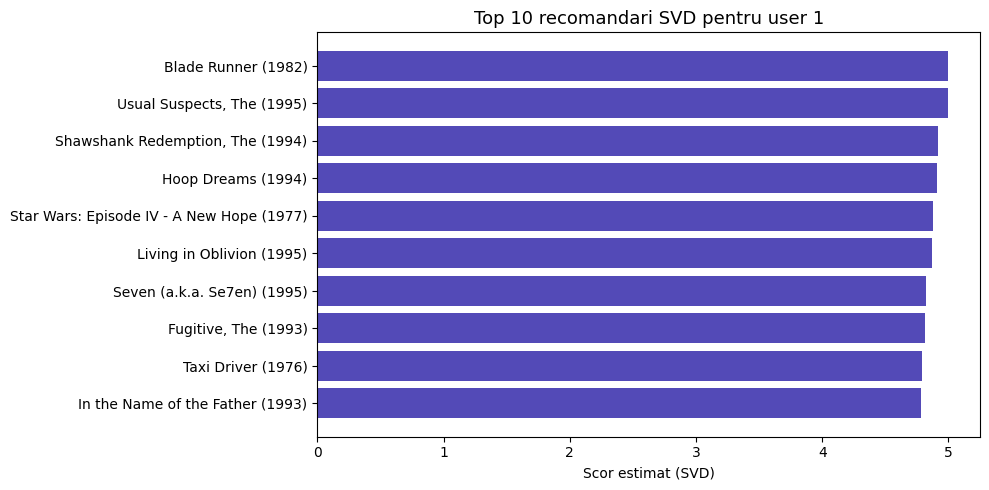

In [ ]:
# Grafic top 10 recomandari SVD
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top10["title"][::-1], top10["collaborative_score"][::-1], color="#534AB7")
ax.set_xlabel("Scor estimat (SVD)")
ax.set_title(f"Top 10 recomandari SVD pentru user {user_id}", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/collaborative_top10.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scores_df["collaborative_score"], bins=40, color="#534AB7", edgecolor="white", linewidth=0.3)
ax.set_xlabel("Scor CF (SVD fold-in)")
ax.set_ylabel("Frecventa")
ax.set_title("Distributia scorurilor CF (SVD)", fontsize=13)
plt.tight_layout()
plt.savefig("../figures/collaborative_distributie_scoruri.png", dpi=150, bbox_inches="tight")
plt.show()